# Distribución de Datos e Histogramas

* Esto es fundamental en `Data Science`, porque antes de entrenar modelos casi siempre haces:
  1. Ver distribución.
  2. Detectar outliers.
  3. Detectar skew.
  4. Decidir transformaciones.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

## Histogramas

* Un histograma muestra: frecuencia de valores en intervalos (`bins`)
* Lo que nos muestra al principio, es la frecuencia que aparecen los datos.
* Para diferencias los datos podemos espeficar la lineas y el color.
* Bins nos ayuda a agrupar, en este caso son 10 datos y pusimos que fueran de 5 barras, agrupará de 2 en 2.
* Muy pocos bins: pierdes detalle.
* Demasiados bins: ruido visual.
* Las barras representan: ***cantidad de observaciones dentro de un intervalo***.
* Por eso el histograma revela la forma de la distribución.
* ***Regla práctica usada en Data Science***
* `bins ≈ sqrt(n)`.

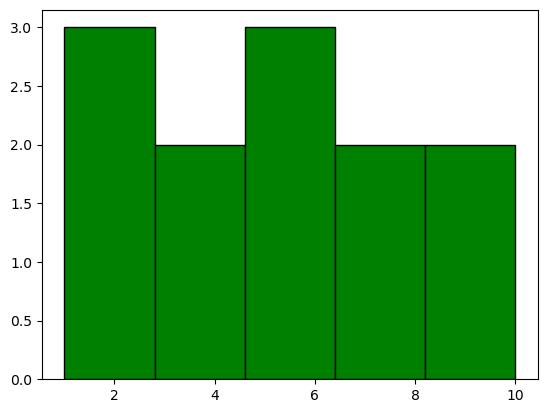

In [2]:
#datos = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
datos = [1, 1, 2, 3, 4, 5, 5, 6, 7, 8, 9, 10]
# Con esta instrucción creamos el histograma
# plt.hist(datos)
plt.hist(datos, bins = 5, color="green", ec="black")
plt.show()

* ¿Qué cambió con `density=True`?
  - Antes tenías: eje Y = número de observaciones (frecuencia).
  - Ahora tenemos: eje Y = densidad de probabilidad.
* Eso significa que el histograma ya no cuenta puntos, sino que se comporta como una distribución de probabilidad.
* El área total bajo el histograma ≈ 1.
* ¿Por qué es útil esto?
* Porque ahora puedes:
  - Comparar distribuciones con diferente tamaño de muestra.
  - Superponer funciones teóricas.
  - Usar KDE.
  - Conectar directamente con modelos probabilísticos.

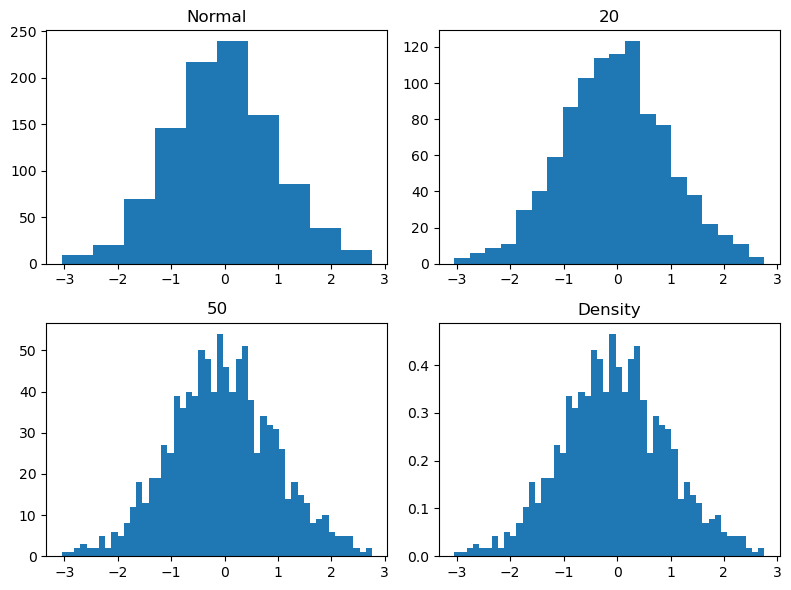

In [5]:
np.random.seed(0)
fig, ax = plt.subplots(2,2, figsize=(8,6))
data = np.random.normal(0,1,1000)

ax[0,0].hist(data)
ax[0,0].set_title("Normal")

ax[0,1].hist(data, bins=20)
ax[0,1].set_title("20")

ax[1,0].hist(data, bins=50)
ax[1,0].set_title("50")

ax[1,1].hist(data, bins=50, density=True)
ax[1,1].set_title("Density")

plt.tight_layout()
plt.show()

## Density

* Estamos comparando: tus datos (histograma) contra una distribución normal teórica.
* En teoria mis datos también siguen una distribución normal.
* Por eso se ve que la linea se ajusta mucho a está función.
* En Data Science: ***Los datos casi nunca son perfectamente normales***.
* Pero muchas veces: son ***“lo suficientemente normales”*** y eso basta.

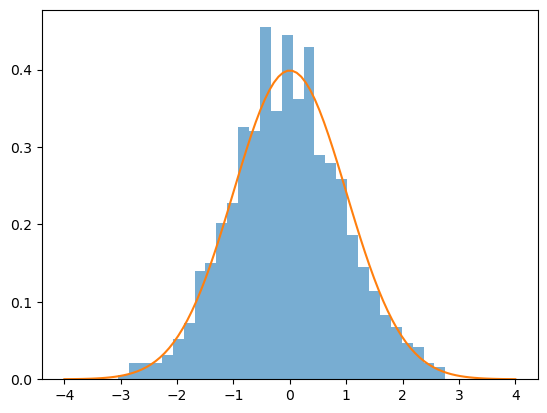

In [8]:
### Mis datos
plt.hist(data, bins=30, density=True, alpha=0.6)

### Distribución Estandar teorica
x = np.linspace(-4,4,100)
y = (1/np.sqrt(2*np.pi)) * np.exp(-x**2 / 2)

plt.plot(x, y)
plt.show()

### KDE (Kernel Density Estimation)

* ***¿Qué hace el KDE?***
  - Dibuja una curva suave estimando la distribución real de tus datos.
  - Es como una versión “inteligente” del histograma.
* `KDE → forma real de la distribución`.

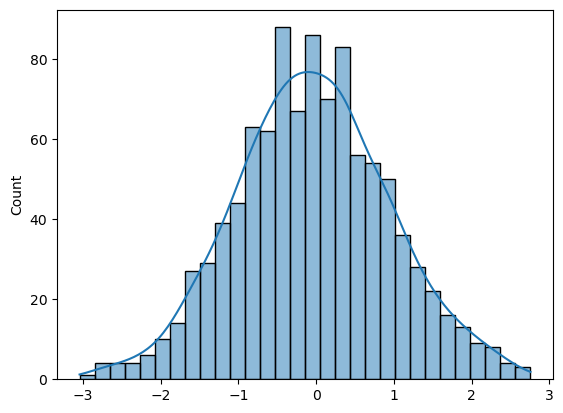

In [9]:
import seaborn as sns

sns.histplot(data, bins=30, kde=True)
plt.show()

## EJERCICIOS

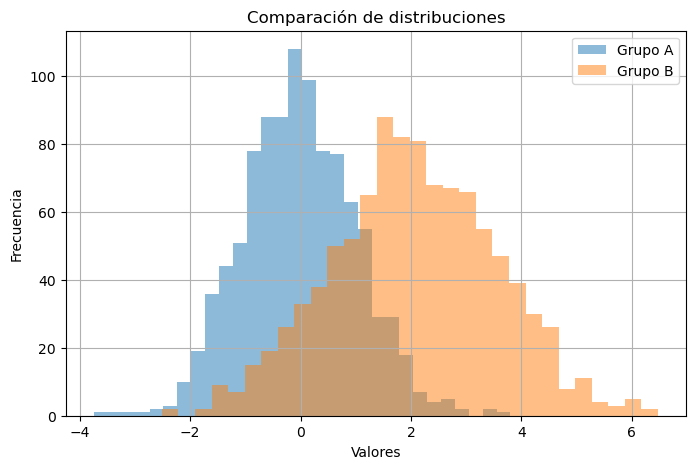

In [11]:
data1 = np.random.normal(0,1,1000)
data2 = np.random.normal(2,1.5,1000)

plt.figure(figsize=(8,5))

plt.hist(data1, bins=30, alpha=0.5, label="Grupo A")
plt.hist(data2, bins=30, alpha=0.5, label="Grupo B")

plt.title("Comparación de distribuciones")
plt.xlabel("Valores")
plt.ylabel("Frecuencia")

plt.legend()
plt.grid(True)

### Guardar la imagen
plt.savefig("comparacion.png", dpi=300)

plt.show()

## Generar arreglos con datos aleatorio.

* Recordemos que ` np.random.rand()`, nos traera números que siguen una distribución normal, es decir números entre 0 y 1.
* Distribución normal: con media de = 0 y desviación estándar de 1 por default.

In [12]:
# Distribución normal con media de 100 y desviación estándar de 10.
data = np.random.normal(loc=100, scale=10, size=1000)
print("\n X Barra:", data.mean())
print("\n Sigma minus (Desviacion estandar):",data.std())


 X Barra: 99.80946730207735

 Sigma minus (Desviacion estandar): 9.83582560897532


## Generación Distribución Normal, Uniforme y Exponencial.

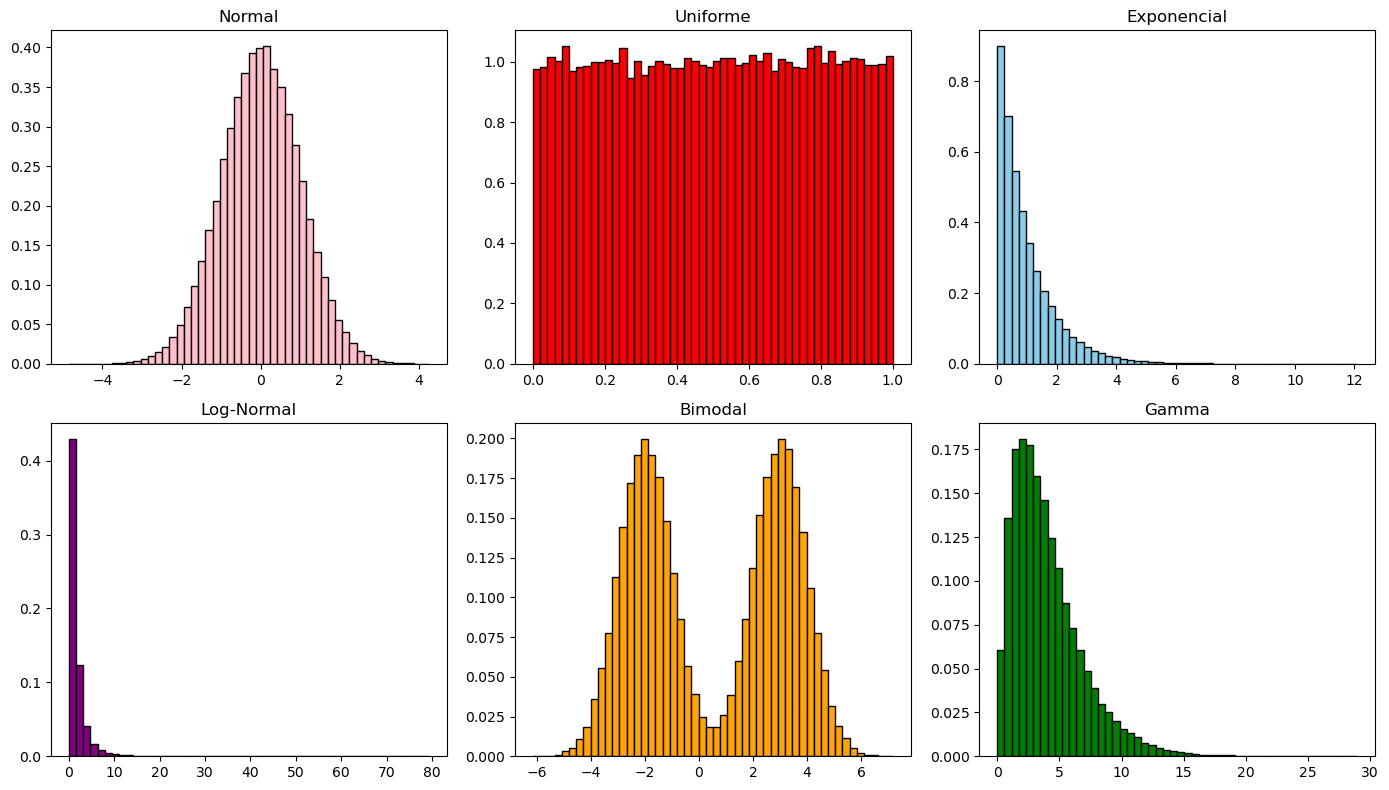

In [14]:
np.random.seed(0)

fig, ax = plt.subplots(2,3, figsize=(14,8))

# 1. Normal
data = np.random.normal(0,1,100000)
ax[0,0].hist(data, bins=50, density=True, color="pink", ec="black")
ax[0,0].set_title("Normal")

# 2. Uniforme
data = np.random.uniform(0,1,100000)
ax[0,1].hist(data, bins=50, density=True, color="red", ec="black")
ax[0,1].set_title("Uniforme")

# 3. Exponencial
data = np.random.exponential(1,100000)
ax[0,2].hist(data, bins=50, density=True, color="skyblue", ec="black")
ax[0,2].set_title("Exponencial")

# 4. Log-normal
data = np.random.lognormal(0,1,100000)
ax[1,0].hist(data, bins=50, density=True, color="purple", ec="black")
ax[1,0].set_title("Log-Normal")

# 5. Bimodal
data1 = np.random.normal(-2,1,50000)
data2 = np.random.normal(3,1,50000)
data = np.concatenate([data1,data2])
ax[1,1].hist(data, bins=50, density=True, color="orange", ec="black")
ax[1,1].set_title("Bimodal")

# 6. (Extra) Gamma
data = np.random.gamma(shape=2, scale=2, size=100000)
ax[1,2].hist(data, bins=50, density=True, color="green", ec="black")
ax[1,2].set_title("Gamma")

plt.tight_layout()
plt.show()